# Epsilon Sweep for `simplify.cpp`

This notebook measures the simplified point count and execution time of `simplify.cpp` for test cases 1--20. The distance parameter is fixed at `300`, and each epsilon uses

```text
d = 300 / (1 + e)
```

The sweep includes `e = 0.5, 1, 2, 3`, followed by 20 evenly spaced samples from `4` through `300`. The notebook records both the algorithm's reported core time (`SIMPLIFY_CORE_MS`) and the Python-measured subprocess wall time.

In [59]:
from pathlib import Path
import re
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "scripts" else Path.cwd().resolve()
if not (REPO_ROOT / "simplify.cpp").exists():
    raise FileNotFoundError(f"Could not locate repository root from {Path.cwd()}")

SIMPLIFY = REPO_ROOT / "build-release" / "simplify"
if not SIMPLIFY.exists():
    fallback = REPO_ROOT / "build" / "simplify"
    if fallback.exists():
        SIMPLIFY = fallback
if not SIMPLIFY.exists():
    raise FileNotFoundError("No simplify binary found in build-release/ or build/")

DISTANCE = 300.0
TEST_CASES = list(range(1, 21))
FIXED_EPSILONS = np.array([0.5, 1.0, 2.0, 3.0])
SAMPLED_EPSILONS = np.linspace(4.0, 300.0, 20)
EPSILONS = np.unique(np.round(np.concatenate([FIXED_EPSILONS, SAMPLED_EPSILONS]), 10))
RESULTS_CSV = REPO_ROOT / "scripts" / "compare_e_results.csv"
print(f"Binary: {SIMPLIFY}")
print(f"{len(TEST_CASES)} test cases x {len(EPSILONS)} epsilon values = {len(TEST_CASES) * len(EPSILONS)} runs")
print("Epsilon values:", EPSILONS)

Binary: /Users/sinchunyeung/Simplification-of-Trajectory-Streams/build-release/simplify
20 test cases x 24 epsilon values = 480 runs
Epsilon values: [  0.5          1.           2.           3.           4.
  19.57894737  35.15789474  50.73684211  66.31578947  81.89473684
  97.47368421 113.05263158 128.63157895 144.21052632 159.78947368
 175.36842105 190.94736842 206.52631579 222.10526316 237.68421053
 253.26315789 268.84210526 284.42105263 300.        ]


In [60]:
CORE_TIME_RE = re.compile(r"SIMPLIFY_CORE_MS:\s*([0-9.eE+-]+)")
POINTS_RE = re.compile(r"Simplified to\s+(\d+)\s+points")

def run_simplify(test_case, epsilon, timeout=600):
    delta = DISTANCE / (1.0 + epsilon)
    command = [str(SIMPLIFY), "--in", str(test_case), "-d", str(delta), "-e", str(epsilon)]
    started = time.perf_counter()
    try:
        completed = subprocess.run(
            command,
            cwd=REPO_ROOT,
            capture_output=True,
            text=True,
            timeout=timeout,
            check=False,
        )
        wall_ms = (time.perf_counter() - started) * 1000.0
    except subprocess.TimeoutExpired as exc:
        wall_ms = (time.perf_counter() - started) * 1000.0
        return {
            "test_case": test_case, "epsilon": epsilon, "delta": delta,
            "simplified_points": np.nan, "core_time_ms": np.nan,
            "wall_time_ms": wall_ms, "status": "timeout",
            "stderr": str(exc),
        }

    output = f"{completed.stdout}\n{completed.stderr}"
    points_match = POINTS_RE.search(output)
    core_match = CORE_TIME_RE.search(output)
    status = "ok" if completed.returncode == 0 and points_match and core_match else "error"
    return {
        "test_case": test_case,
        "epsilon": epsilon,
        "delta": delta,
        "simplified_points": int(points_match.group(1)) if points_match else np.nan,
        "core_time_ms": float(core_match.group(1)) if core_match else np.nan,
        "wall_time_ms": wall_ms,
        "status": status,
        "stderr": completed.stderr[-1000:],
    }

def run_sweep(force_rerun=True):
    if not force_rerun and RESULTS_CSV.exists():
        cached = pd.read_csv(RESULTS_CSV)
        cached["epsilon"] = cached["epsilon"].astype(float)
        return cached

    records = []
    total = len(TEST_CASES) * len(EPSILONS)
    for run_number, (test_case, epsilon) in enumerate(
        ((case, eps) for case in TEST_CASES for eps in EPSILONS), start=1
    ):
        record = run_simplify(test_case, float(epsilon))
        records.append(record)
        print(
            f"[{run_number:>3}/{total}] case={test_case:>2} e={epsilon:>7.2f} "
            f"d={record['delta']:>8.3f} points={record['simplified_points']} "
            f"core={record['core_time_ms']:.2f} ms status={record['status']}"
        )

    results = pd.DataFrame(records)
    results.to_csv(RESULTS_CSV, index=False)
    return results

In [61]:
# Set force_rerun=False to reuse a completed CSV and avoid repeating the sweep.
results = run_sweep(force_rerun=True)
results.head()

[  1/480] case= 1 e=   0.50 d= 200.000 points=86 core=106.98 ms status=ok
[  2/480] case= 1 e=   1.00 d= 150.000 points=88 core=33.30 ms status=ok
[  3/480] case= 1 e=   2.00 d= 100.000 points=92 core=7.58 ms status=ok
[  4/480] case= 1 e=   3.00 d=  75.000 points=90 core=11.62 ms status=ok
[  5/480] case= 1 e=   4.00 d=  60.000 points=90 core=11.67 ms status=ok
[  6/480] case= 1 e=  19.58 d=  14.578 points=92 core=4.27 ms status=ok
[  7/480] case= 1 e=  35.16 d=   8.297 points=92 core=4.70 ms status=ok
[  8/480] case= 1 e=  50.74 d=   5.799 points=90 core=3.86 ms status=ok
[  9/480] case= 1 e=  66.32 d=   4.457 points=90 core=3.69 ms status=ok
[ 10/480] case= 1 e=  81.89 d=   3.619 points=92 core=4.66 ms status=ok
[ 11/480] case= 1 e=  97.47 d=   3.046 points=92 core=4.33 ms status=ok
[ 12/480] case= 1 e= 113.05 d=   2.630 points=90 core=3.81 ms status=ok
[ 13/480] case= 1 e= 128.63 d=   2.314 points=90 core=3.99 ms status=ok
[ 14/480] case= 1 e= 144.21 d=   2.066 points=90 core=3.85 

,test_case,epsilon,delta,simplified_points,core_time_ms,wall_time_ms,status,stderr
0,1,0.5,200.0,86,106.9829,131.812083,ok,
1,1,1.0,150.0,88,33.3040,46.621291,ok,
2,1,2.0,100.0,92,7.5833,14.576416,ok,
3,1,3.0,75.0,90,11.6203,18.094875,ok,
4,1,4.0,60.0,90,11.6680,17.644750,ok,


In [62]:
ok = results[results["status"] == "ok"].copy()
print(f"Successful runs: {len(ok)} / {len(results)}")
if len(ok) < len(results):
    display(results[results["status"] != "ok"][
        ["test_case", "epsilon", "delta", "status", "stderr"]
    ])

summary = (
    ok.groupby("epsilon", as_index=False)
    .agg(
        median_points=("simplified_points", "median"),
        mean_points=("simplified_points", "mean"),
        median_core_ms=("core_time_ms", "median"),
        median_wall_ms=("wall_time_ms", "median"),
        cases=("test_case", "count"),
    )
)
summary

Successful runs: 480 / 480


,epsilon,median_points,mean_points,median_core_ms,median_wall_ms,cases
0,0.500000,111.0,119.1,144.08960,151.076521,20
1,1.000000,112.0,121.5,55.30615,65.483479,20
2,2.000000,130.0,132.5,9.07890,17.948896,20
3,3.000000,118.0,125.7,15.27485,22.688083,20
4,4.000000,119.0,128.8,15.22920,21.784021,20
5,19.578947,132.0,135.6,4.86390,11.133979,20
6,35.157895,130.0,134.1,4.81385,13.749667,20
7,50.736842,130.0,133.5,5.08050,11.701125,20
8,66.315789,133.0,133.3,5.17260,11.187750,20
9,81.894737,133.0,133.3,4.85680,12.055250,20


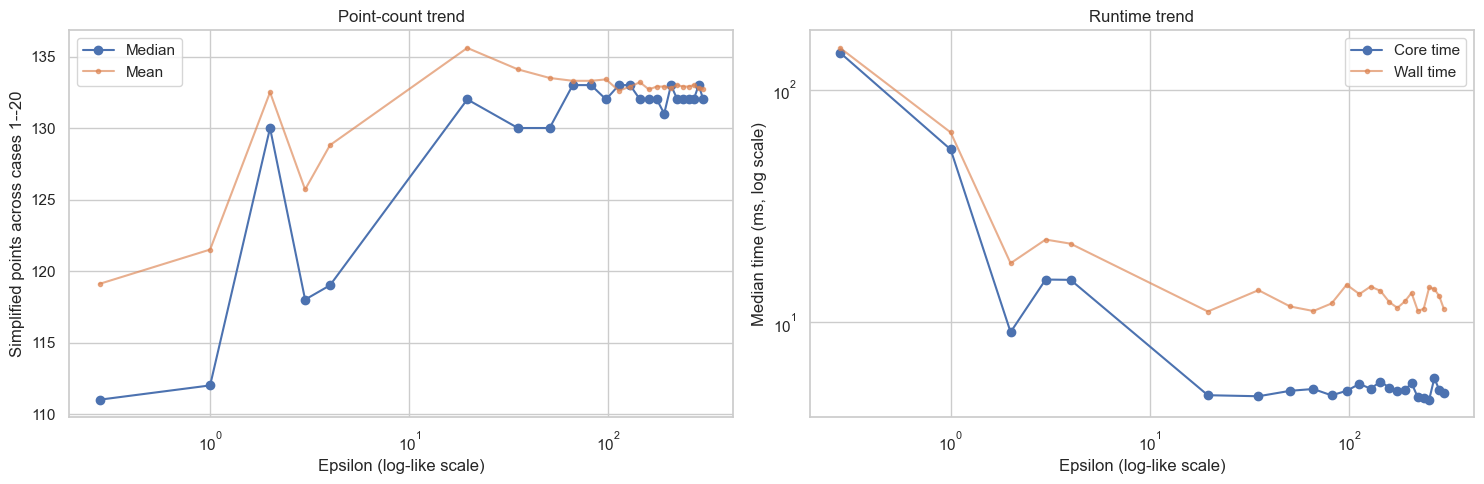

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(summary["epsilon"], summary["median_points"], marker="o", label="Median")
axes[0].plot(summary["epsilon"], summary["mean_points"], marker=".", alpha=0.65, label="Mean")
axes[0].set_xscale("symlog", linthresh=1)
axes[0].set_xlabel("Epsilon (log-like scale)")
axes[0].set_ylabel("Simplified points across cases 1--20")
axes[0].set_title("Point-count trend")
axes[0].legend()

axes[1].plot(summary["epsilon"], summary["median_core_ms"], marker="o", label="Core time")
axes[1].plot(summary["epsilon"], summary["median_wall_ms"], marker=".", alpha=0.65, label="Wall time")
axes[1].set_xscale("symlog", linthresh=1)
axes[1].set_yscale("log")
axes[1].set_xlabel("Epsilon (log-like scale)")
axes[1].set_ylabel("Median time (ms, log scale)")
axes[1].set_title("Runtime trend")
axes[1].legend()

plt.tight_layout()
plt.show()

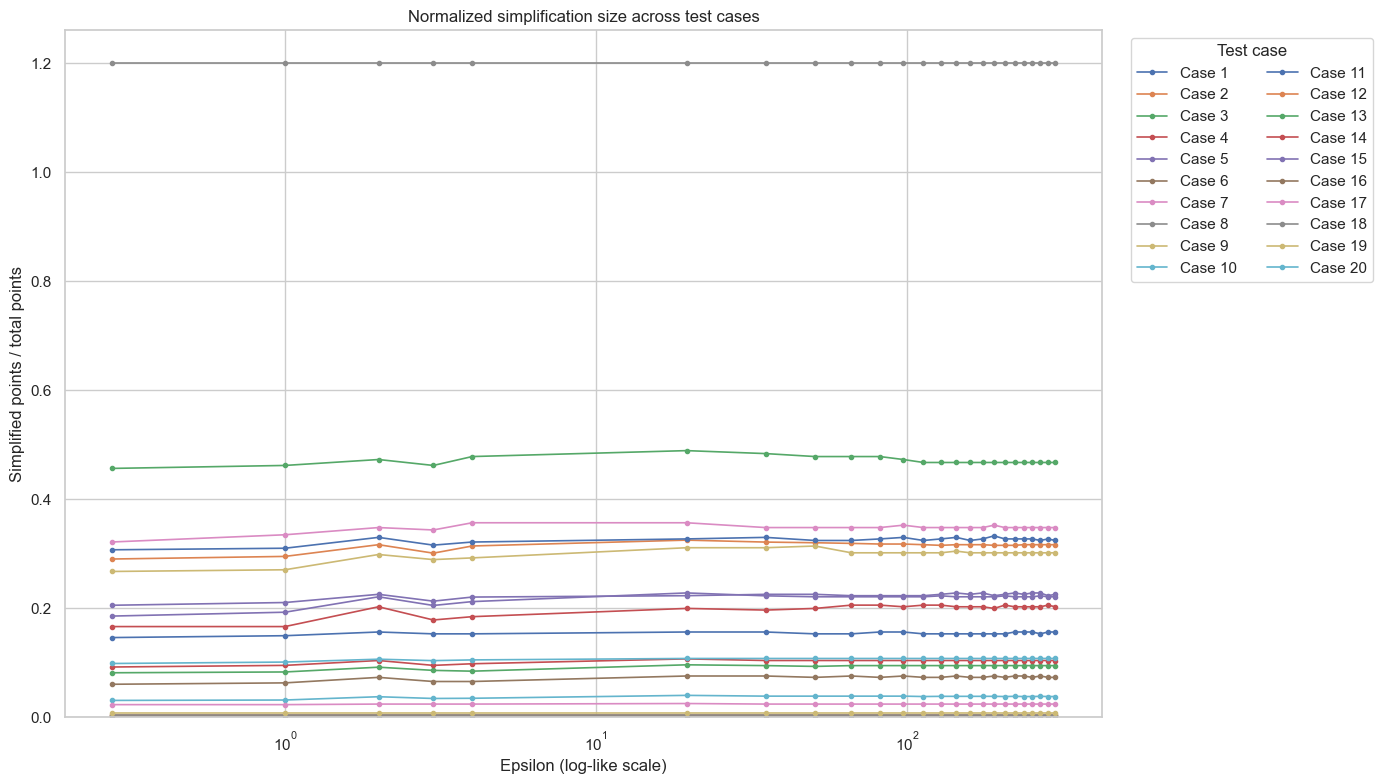

,test_case,epsilon,simplified_points,total_points,point_ratio
0,1,0.5,86,588,0.146259
1,1,1.0,88,588,0.149660
2,1,2.0,92,588,0.156463
3,1,3.0,90,588,0.153061
4,1,4.0,90,588,0.153061


In [64]:
total_points = {
    case: int((REPO_ROOT / "data" / str(case) / "original.txt").read_text().splitlines()[0])
    for case in TEST_CASES
}
normalized = ok.copy()
normalized["total_points"] = normalized["test_case"].map(total_points)
normalized["point_ratio"] = normalized["simplified_points"] / normalized["total_points"]

fig, ax = plt.subplots(figsize=(14, 8))
for case, case_data in normalized.groupby("test_case"):
    case_data = case_data.sort_values("epsilon")
    ax.plot(
        case_data["epsilon"],
        case_data["point_ratio"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label=f"Case {case}",
    )

ax.set_xscale("symlog", linthresh=1)
ax.set_xlabel("Epsilon (log-like scale)")
ax.set_ylabel("Simplified points / total points")
ax.set_ylim(bottom=0)
ax.set_title("Normalized simplification size across test cases")
ax.legend(title="Test case", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

normalized[["test_case", "epsilon", "simplified_points", "total_points", "point_ratio"]].head()

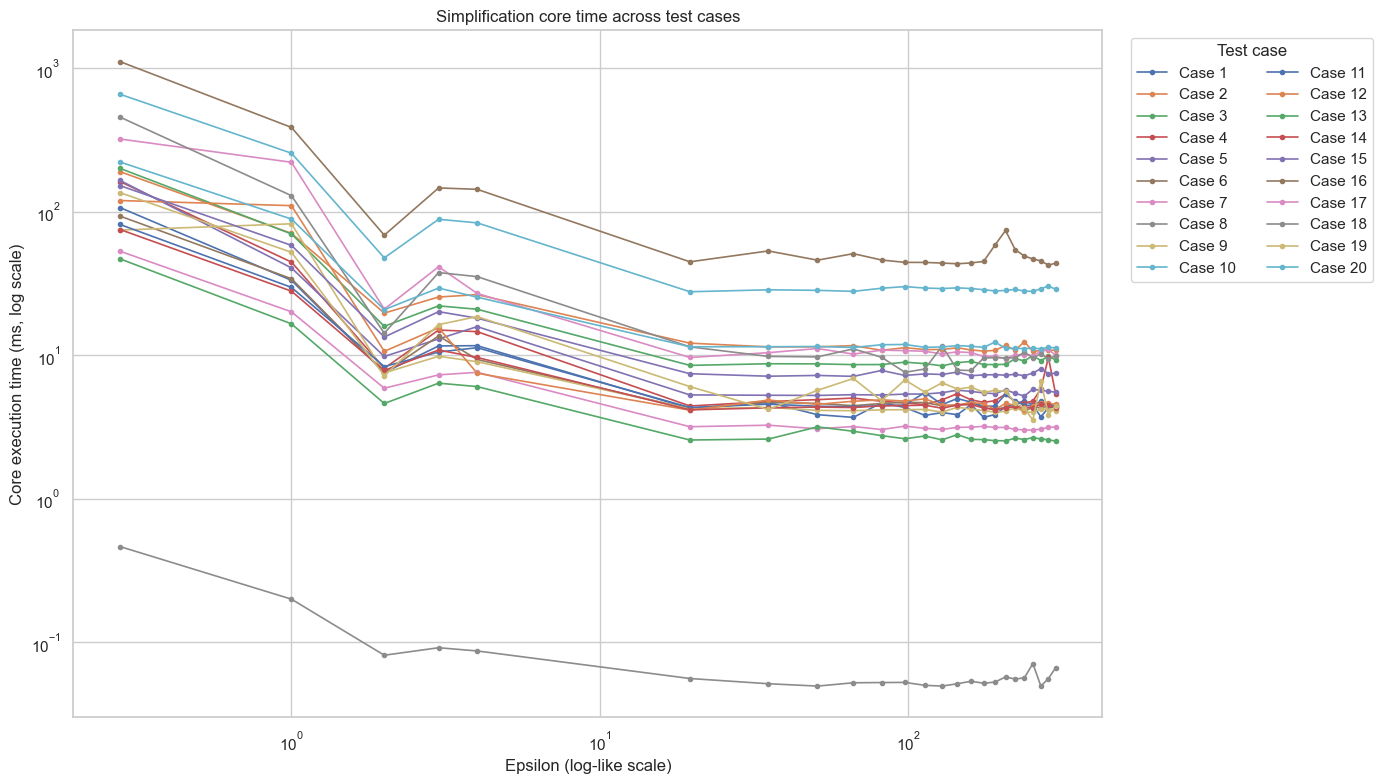

,test_case,epsilon,core_time_ms
0,1,0.5,106.9829
1,1,1.0,33.3040
2,1,2.0,7.5833
3,1,3.0,11.6203
4,1,4.0,11.6680


In [65]:
fig, ax = plt.subplots(figsize=(14, 8))
for case, case_data in ok.groupby("test_case"):
    case_data = case_data.sort_values("epsilon")
    ax.plot(
        case_data["epsilon"],
        case_data["core_time_ms"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label=f"Case {case}",
    )

ax.set_xscale("symlog", linthresh=1)
ax.set_yscale("log")
ax.set_xlabel("Epsilon (log-like scale)")
ax.set_ylabel("Core execution time (ms, log scale)")
ax.set_title("Simplification core time across test cases")
ax.legend(title="Test case", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

ok[["test_case", "epsilon", "core_time_ms"]].head()

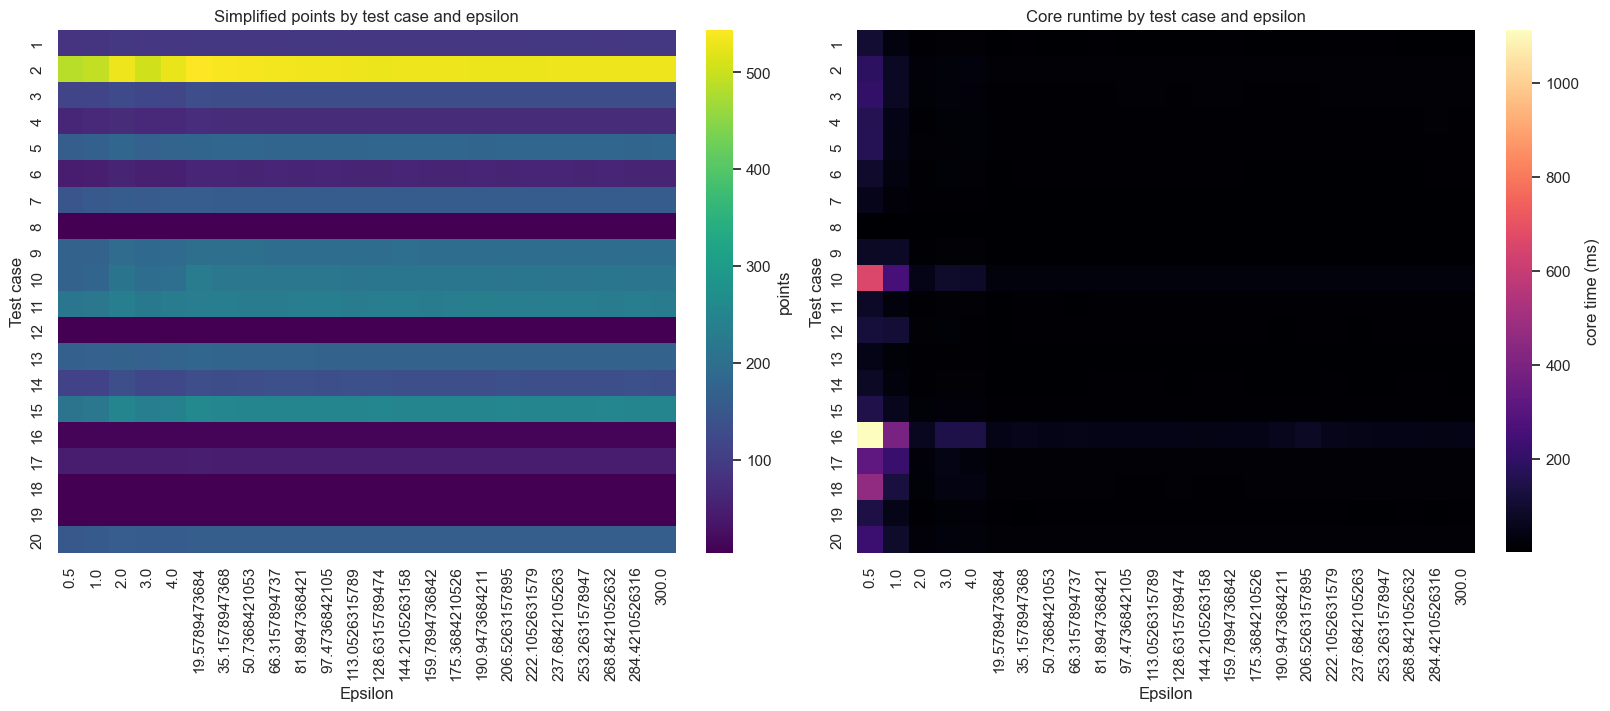

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

point_table = ok.pivot(index="test_case", columns="epsilon", values="simplified_points")
sns.heatmap(point_table, ax=axes[0], cmap="viridis", cbar_kws={"label": "points"})
axes[0].set_title("Simplified points by test case and epsilon")
axes[0].set_xlabel("Epsilon")
axes[0].set_ylabel("Test case")

time_table = ok.pivot(index="test_case", columns="epsilon", values="core_time_ms")
sns.heatmap(time_table, ax=axes[1], cmap="magma", cbar_kws={"label": "core time (ms)"})
axes[1].set_title("Core runtime by test case and epsilon")
axes[1].set_xlabel("Epsilon")
axes[1].set_ylabel("Test case")

plt.show()

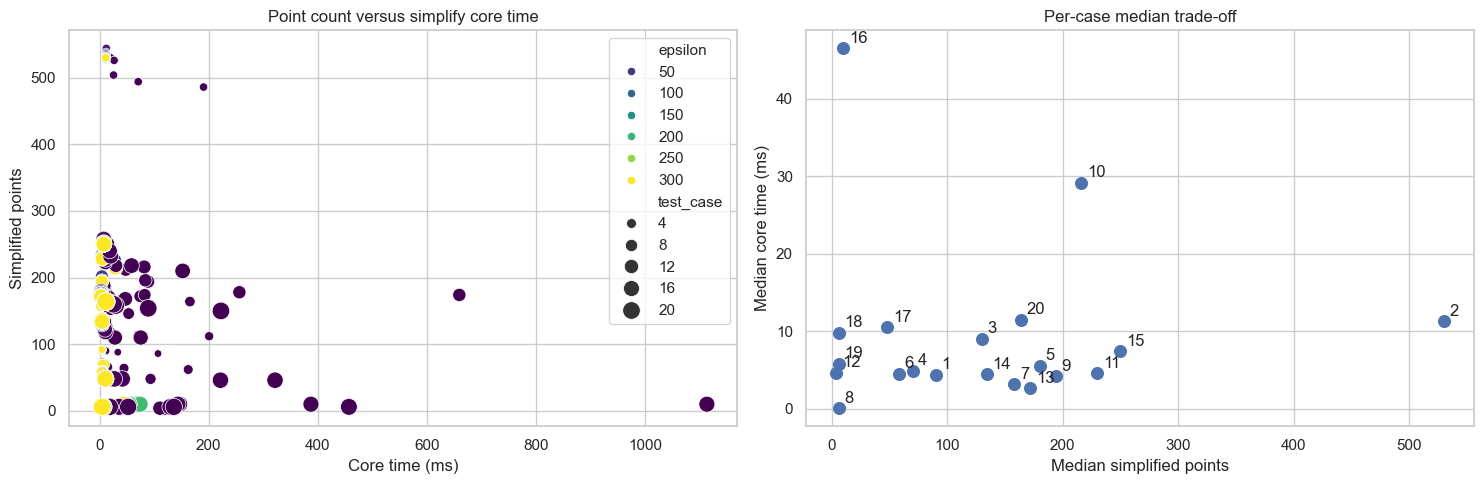

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=ok, x="core_time_ms", y="simplified_points",
    hue="epsilon", size="test_case", palette="viridis",
    sizes=(30, 160), ax=axes[0]
)
axes[0].set_title("Point count versus simplify core time")
axes[0].set_xlabel("Core time (ms)")
axes[0].set_ylabel("Simplified points")

case_summary = (
    ok.groupby("test_case", as_index=False)
    .agg(
        median_points=("simplified_points", "median"),
        median_core_ms=("core_time_ms", "median"),
    )
)
axes[1].scatter(case_summary["median_points"], case_summary["median_core_ms"], s=70)
for row in case_summary.itertuples():
    axes[1].annotate(str(row.test_case), (row.median_points, row.median_core_ms), xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("Median simplified points")
axes[1].set_ylabel("Median core time (ms)")
axes[1].set_title("Per-case median trade-off")

plt.tight_layout()
plt.show()

The raw measurements are saved to `scripts/compare_e_results.csv` when the sweep runs. The CSV includes one row per `(test_case, epsilon)` pair, the derived `delta`, simplified point count, core time, wall time, status, and the final error text for failed runs.

In [69]:
# Use separate objectives: one epsilon minimizes output size, the other minimizes core time.
def best_for(frame, metric, tie_breaker):
    return frame.sort_values([metric, tie_breaker, "epsilon"]).iloc[0]


recommendations = []
for case, case_data in normalized.groupby("test_case"):
    best_points = best_for(case_data, "point_ratio", "core_time_ms")
    best_time = best_for(case_data, "core_time_ms", "point_ratio")
    recommendations.append({
        "test_case": case,
        "points_epsilon": best_points["epsilon"],
        "points_delta": best_points["delta"],
        "minimum_points": int(best_points["simplified_points"]),
        "minimum_point_ratio": best_points["point_ratio"],
        "points_choice_time_ms": best_points["core_time_ms"],
        "time_epsilon": best_time["epsilon"],
        "time_delta": best_time["delta"],
        "minimum_time_ms": best_time["core_time_ms"],
        "time_choice_points": int(best_time["simplified_points"]),
        "time_choice_point_ratio": best_time["point_ratio"],
    })

per_case_recommendation = pd.DataFrame(recommendations)

# Aggregate with medians so no single large test case dominates the recommendation.
global_scores = (
    normalized.groupby("epsilon", as_index=False)
    .agg(median_point_ratio=("point_ratio", "median"), median_core_time_ms=("core_time_ms", "median"))
)
best_points_global = best_for(global_scores, "median_point_ratio", "median_core_time_ms")
best_time_global = best_for(global_scores, "median_core_time_ms", "median_point_ratio")

print(
    f"Best epsilon for fewest points: {best_points_global.epsilon:.2f} "
    f"(d={DISTANCE / (1 + best_points_global.epsilon):.3f}, "
    f"median point ratio={best_points_global.median_point_ratio:.3f}, "
    f"median core time={best_points_global.median_core_time_ms:.2f} ms)"
)
print(
    f"Best epsilon for speed: {best_time_global.epsilon:.2f} "
    f"(d={DISTANCE / (1 + best_time_global.epsilon):.3f}, "
    f"median point ratio={best_time_global.median_point_ratio:.3f}, "
    f"median core time={best_time_global.median_core_time_ms:.2f} ms)"
)
display(per_case_recommendation)
display(global_scores.sort_values("median_point_ratio").head(10))
display(global_scores.sort_values("median_core_time_ms").head(10))

Best epsilon for fewest points: 0.50 (d=200.000, median point ratio=0.122, median core time=144.09 ms)
Best epsilon for speed: 253.26 (d=1.180, median point ratio=0.132, median core time=4.65 ms)


,test_case,points_epsilon,points_delta,minimum_points,minimum_point_ratio,points_choice_time_ms,time_epsilon,time_delta,minimum_time_ms,time_choice_points,time_choice_point_ratio
0,1,0.500000,200.000000,86,0.146259,106.9829,66.315789,4.456607,3.6920,90,0.153061
1,2,0.500000,200.000000,486,0.290323,190.4834,253.263158,1.179880,10.6294,530,0.316607
2,3,0.500000,200.000000,112,0.081692,200.7237,128.631579,2.314251,8.4456,130,0.094821
3,4,0.500000,200.000000,62,0.092262,162.3565,19.578947,14.578005,4.4335,72,0.107143
4,5,0.500000,200.000000,164,0.205514,165.4859,237.684211,1.256891,5.1973,180,0.225564
5,6,0.500000,200.000000,48,0.060606,93.3185,237.684211,1.256891,4.1001,60,0.075758
6,7,0.500000,200.000000,146,0.321586,53.1270,253.263158,1.179880,3.0075,158,0.348018
7,8,50.736842,5.798576,6,1.200000,0.0495,50.736842,5.798576,0.0495,6,1.200000
8,9,0.500000,200.000000,172,0.267496,74.5699,253.263158,1.179880,4.0111,194,0.301711
9,10,0.500000,200.000000,174,0.030977,659.4750,19.578947,14.578005,27.7252,226,0.040235


,epsilon,median_point_ratio,median_core_time_ms
0,0.500000,0.122471,144.08960
1,1.000000,0.125488,55.30615
3,3.000000,0.128504,15.27485
4,4.000000,0.129162,15.22920
21,268.842105,0.130478,5.75555
17,206.526316,0.130478,5.48600
16,190.947368,0.130478,5.11125
15,175.368421,0.130478,5.08500
14,159.789474,0.130478,5.24480
13,144.210526,0.130478,5.56070


,epsilon,median_point_ratio,median_core_time_ms
20,253.263158,0.132179,4.65190
19,237.684211,0.132179,4.72620
18,222.105263,0.132179,4.75930
6,35.157895,0.132179,4.81385
9,81.894737,0.132179,4.85680
5,19.578947,0.132179,4.86390
23,300.000000,0.132179,4.97325
7,50.736842,0.130478,5.08050
10,97.473684,0.132179,5.08075
15,175.368421,0.130478,5.08500
